In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import os
import urllib.request
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# YOUR PATHS
BASE_PATH = 'C:/Users/Sunrise Computer/Desktop/DecodeLabs_Internship'
DATA_PATH = BASE_PATH + '/datasets'
OUTPUT_PATH = BASE_PATH + '/outputs'

if not os.path.exists(DATA_PATH):
    os.makedirs(DATA_PATH)
if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)

print("✅ All libraries imported!")
print(f"📁 Data path: {DATA_PATH}")
print(f"📁 Output path: {OUTPUT_PATH}")

✅ All libraries imported!
📁 Data path: C:/Users/Sunrise Computer/Desktop/DecodeLabs_Internship/datasets
📁 Output path: C:/Users/Sunrise Computer/Desktop/DecodeLabs_Internship/outputs


In [2]:
data_file = DATA_PATH + '/mall_customers.csv'

if os.path.exists(data_file):
    print("✅ Dataset already exists!")
else:
    print("📥 Downloading...")
    url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"
    urllib.request.urlretrieve(url, data_file)
    print("✅ Downloaded!")

df = pd.read_csv(data_file)

print("\n" + "="*60)
print("CUSTOMER SEGMENTATION DATASET")
print("="*60)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df.head())

✅ Dataset already exists!

CUSTOMER SEGMENTATION DATASET
Shape: 200 rows × 5 columns

Columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

First 5 rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [3]:
print("="*60)
print("DATA EXPLORATION")
print("="*60)

print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nStatistical Summary:")
print(df.describe().round(2))

if 'Gender' in df.columns:
    print(f"\nGender Distribution:")
    print(df['Gender'].value_counts())

DATA EXPLORATION

Missing values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Data types:
CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

Statistical Summary:
       CustomerID     Age  Annual Income (k$)  Spending Score (1-100)
count      200.00  200.00              200.00                  200.00
mean       100.50   38.85               60.56                   50.20
std         57.88   13.97               26.26                   25.82
min          1.00   18.00               15.00                    1.00
25%         50.75   28.75               41.50                   34.75
50%        100.50   36.00               61.50                   50.00
75%        150.25   49.00               78.00                   73.00
max        200.00   70.00              137.0

In [4]:
print("="*60)
print("PREPARING DATA")
print("="*60)

if 'CustomerID' in df.columns:
    df = df.drop(columns=['CustomerID'])
    print("✅ Dropped CustomerID column")

if 'Gender' in df.columns:
    df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
    print("✅ Encoded Gender: Male=0, Female=1")

print(f"\nFinal shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df.head())

PREPARING DATA
✅ Dropped CustomerID column
✅ Encoded Gender: Male=0, Female=1

Final shape: (200, 4)
Columns: ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

First 5 rows:
   Gender  Age  Annual Income (k$)  Spending Score (1-100)
0       0   19                  15                      39
1       0   21                  15                      81
2       1   20                  16                       6
3       1   23                  16                      77
4       1   31                  17                      40


In [5]:
print("="*60)
print("STANDARDIZATION")
print("="*60)

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

print("✅ Data standardized!")
print(f"\nMean (should be ~0):")
print(df_scaled.mean().round(4))
print(f"\nStd (should be ~1):")
print(df_scaled.std().round(4))

STANDARDIZATION
✅ Data standardized!

Mean (should be ~0):
Gender                   -0.0
Age                      -0.0
Annual Income (k$)       -0.0
Spending Score (1-100)   -0.0
dtype: float64

Std (should be ~1):
Gender                    1.0025
Age                       1.0025
Annual Income (k$)        1.0025
Spending Score (1-100)    1.0025
dtype: float64


PRINCIPAL COMPONENT ANALYSIS (PCA)
Explained Variance per Component:
  PC1: 0.3369 (33.6900% cumulative)
  PC2: 0.2623 (59.9207% cumulative)
  PC3: 0.2326 (83.1813% cumulative)
  PC4: 0.1682 (100.0000% cumulative)

✅ Components needed for 95% variance: 4
✅ Saved: pca_variance.png


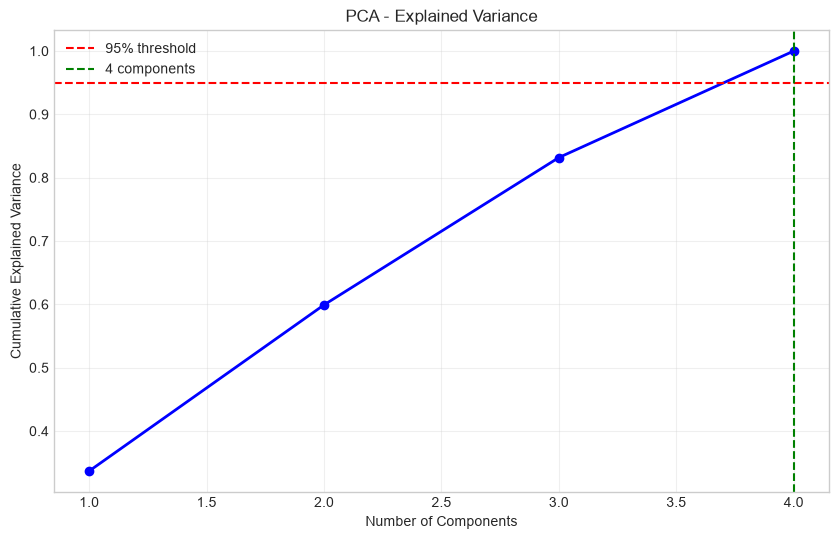

In [6]:
print("="*60)
print("PRINCIPAL COMPONENT ANALYSIS (PCA)")
print("="*60)

pca = PCA()
pca_result = pca.fit_transform(df_scaled)

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print("Explained Variance per Component:")
for i, (var, cum_var) in enumerate(zip(explained_var, cumulative_var)):
    print(f"  PC{i+1}: {var:.4f} ({cum_var:.4%} cumulative)")

n_components_95 = np.argmax(cumulative_var >= 0.95) + 1
print(f"\n✅ Components needed for 95% variance: {n_components_95}")

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, 'bo-', linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.axvline(x=n_components_95, color='g', linestyle='--', label=f'{n_components_95} components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Explained Variance')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(OUTPUT_PATH + '/pca_variance.png', dpi=300, bbox_inches='tight')
print("✅ Saved: pca_variance.png")
plt.show()

In [7]:
print("="*60)
print("2D PCA PROJECTION")
print("="*60)

pca_2d = PCA(n_components=2)
pca_2d_result = pca_2d.fit_transform(df_scaled)

pca_df = pd.DataFrame(pca_2d_result, columns=['PC1', 'PC2'])

print(f"Variance explained by PC1: {pca_2d.explained_variance_ratio_[0]:.4%}")
print(f"Variance explained by PC2: {pca_2d.explained_variance_ratio_[1]:.4%}")
print(f"Total variance explained: {pca_2d.explained_variance_ratio_.sum():.4%}")

2D PCA PROJECTION
Variance explained by PC1: 33.6900%
Variance explained by PC2: 26.2306%
Total variance explained: 59.9207%


ELBOW METHOD - Finding Optimal K
K=1: WCSS = 479.37
K=2: WCSS = 272.16
K=3: WCSS = 187.91
K=4: WCSS = 125.49
K=5: WCSS = 104.78
K=6: WCSS = 86.82
K=7: WCSS = 73.85
K=8: WCSS = 66.41
K=9: WCSS = 57.95
K=10: WCSS = 51.68
✅ Saved: elbow_method.png


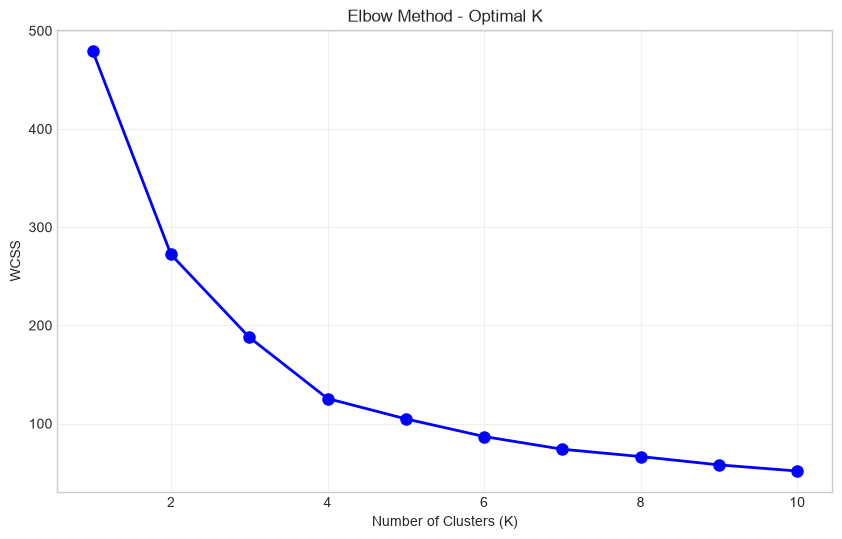

In [8]:
print("="*60)
print("ELBOW METHOD - Finding Optimal K")
print("="*60)

wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(pca_2d_result)
    wcss.append(kmeans.inertia_)
    print(f"K={k}: WCSS = {kmeans.inertia_:.2f}")

plt.figure(figsize=(10, 6))
plt.plot(K_range, wcss, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method - Optimal K')
plt.grid(alpha=0.3)
plt.savefig(OUTPUT_PATH + '/elbow_method.png', dpi=300, bbox_inches='tight')
print("✅ Saved: elbow_method.png")
plt.show()

SILHOUETTE SCORE - Validating K
K=2: Silhouette Score = 0.4014
K=3: Silhouette Score = 0.3887
K=4: Silhouette Score = 0.4164
K=5: Silhouette Score = 0.3878
K=6: Silhouette Score = 0.3940
K=7: Silhouette Score = 0.3806
K=8: Silhouette Score = 0.3643
K=9: Silhouette Score = 0.3663
K=10: Silhouette Score = 0.3835

🏆 Best K: 4
   Score: 0.4164
✅ Saved: silhouette_score.png


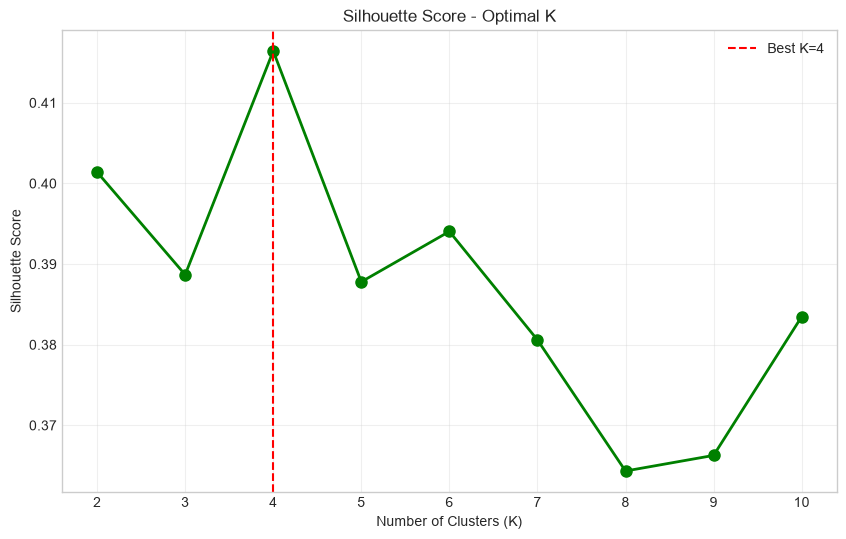

In [9]:
print("="*60)
print("SILHOUETTE SCORE - Validating K")
print("="*60)

silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pca_2d_result)
    score = silhouette_score(pca_2d_result, labels)
    silhouette_scores.append(score)
    print(f"K={k}: Silhouette Score = {score:.4f}")

best_k_idx = np.argmax(silhouette_scores)
best_k = K_range[best_k_idx]
best_score = silhouette_scores[best_k_idx]

print(f"\n🏆 Best K: {best_k}")
print(f"   Score: {best_score:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Best K={best_k}')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score - Optimal K')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(OUTPUT_PATH + '/silhouette_score.png', dpi=300, bbox_inches='tight')
print("✅ Saved: silhouette_score.png")
plt.show()

In [10]:
print("="*60)
print("K-MEANS CLUSTERING")
print("="*60)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(pca_2d_result)

pca_df['Cluster'] = cluster_labels
df['Cluster'] = cluster_labels

print(f"✅ Clustering complete with K={best_k}")
print(f"\nCluster Distribution:")
print(df['Cluster'].value_counts().sort_index())

K-MEANS CLUSTERING
✅ Clustering complete with K=4

Cluster Distribution:
Cluster
0    34
1    51
2    54
3    61
Name: count, dtype: int64


✅ Saved: customer_clusters.png


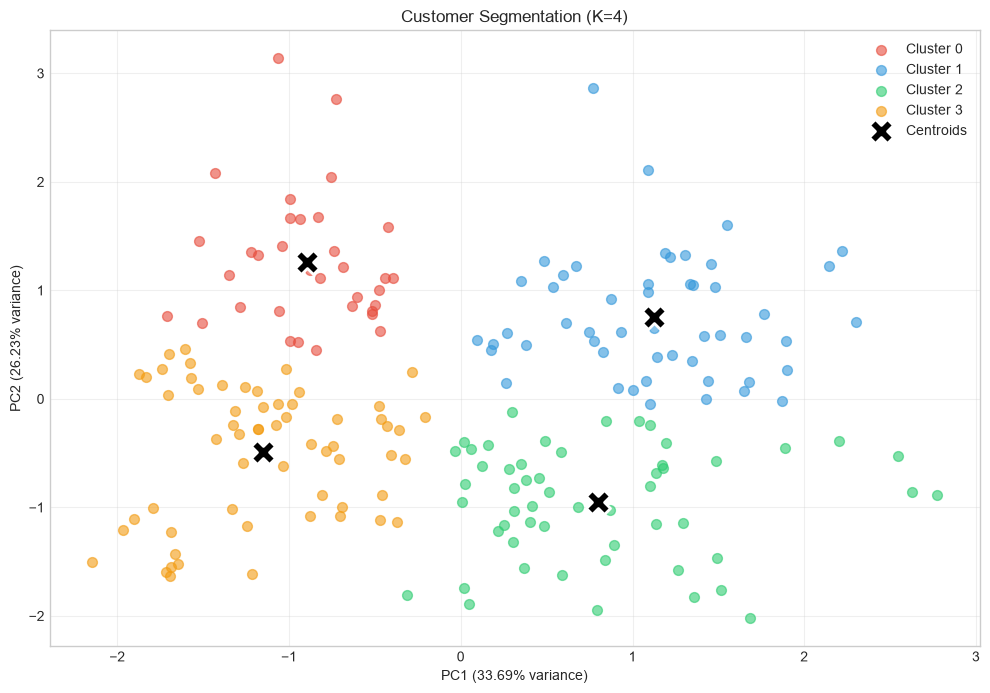

In [11]:
plt.figure(figsize=(12, 8))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', 
          '#1abc9c', '#e67e22', '#34495e']

for i in range(best_k):
    cluster_data = pca_df[pca_df['Cluster'] == i]
    plt.scatter(cluster_data['PC1'], cluster_data['PC2'],
                c=colors[i % len(colors)], label=f'Cluster {i}',
                alpha=0.6, s=50)

centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='black', marker='X', s=300, edgecolors='white',
            linewidths=2, label='Centroids')

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} variance)')
plt.title(f'Customer Segmentation (K={best_k})')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(OUTPUT_PATH + '/customer_clusters.png', dpi=300, bbox_inches='tight')
print("✅ Saved: customer_clusters.png")
plt.show()

In [12]:
print("="*60)
print("CLUSTER ANALYSIS")
print("="*60)

original_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
available_cols = [col for col in original_cols if col in df.columns]

cluster_summary = df.groupby('Cluster')[available_cols].mean().round(2)
cluster_summary['Size'] = df.groupby('Cluster').size()
cluster_summary['Percentage'] = (cluster_summary['Size'] / len(df) * 100).round(1)

print("\nCLUSTER PROFILES:")
print(cluster_summary)

CLUSTER ANALYSIS

CLUSTER PROFILES:
           Age  Annual Income (k$)  Spending Score (1-100)  Size  Percentage
Cluster                                                                     
0        29.91               81.50                   73.88    34        17.0
1        47.65               74.63                   30.86    51        25.5
2        49.22               46.22                   34.00    54        27.0
3        27.30               49.82                   67.51    61        30.5


In [13]:
print("="*60)
print("CUSTOMER PERSONAS")
print("="*60)

for i in range(best_k):
    cluster_data = cluster_summary.loc[i]
    print(f"\n🎯 Cluster {i} ({cluster_data['Size']} customers, {cluster_data['Percentage']}%):")
    
    if 'Annual Income (k$)' in available_cols and 'Spending Score (1-100)' in available_cols:
        income = cluster_data['Annual Income (k$)']
        spending = cluster_data['Spending Score (1-100)']
        age = cluster_data['Age'] if 'Age' in available_cols else 0
        
        if income > 70 and spending > 60:
            persona = "💎 Premium Spenders"
            action = "Exclusive offers, VIP treatment"
        elif income > 70 and spending < 40:
            persona = "💰 Conservative Affluent"
            action = "High-quality products, warranties"
        elif income < 40 and spending > 60:
            persona = "🔥 Budget Enthusiasts"
            action = "Flash sales, discounts, BNPL"
        elif income < 40 and spending < 40:
            persona = "⚠️ Cautious Minimizers"
            action = "Value pricing, basic utility"
        else:
            persona = "📊 Mid-Tier Explorers"
            action = "Loyalty programs, curated recommendations"
        
        print(f"   Persona: {persona}")
        print(f"   Age: {age:.1f} | Income: ${income:.1f}k | Spending: {spending:.1f}/100")
        print(f"   Action: {action}")

CUSTOMER PERSONAS

🎯 Cluster 0 (34.0 customers, 17.0%):
   Persona: 💎 Premium Spenders
   Age: 29.9 | Income: $81.5k | Spending: 73.9/100
   Action: Exclusive offers, VIP treatment

🎯 Cluster 1 (51.0 customers, 25.5%):
   Persona: 💰 Conservative Affluent
   Age: 47.6 | Income: $74.6k | Spending: 30.9/100
   Action: High-quality products, warranties

🎯 Cluster 2 (54.0 customers, 27.0%):
   Persona: 📊 Mid-Tier Explorers
   Age: 49.2 | Income: $46.2k | Spending: 34.0/100
   Action: Loyalty programs, curated recommendations

🎯 Cluster 3 (61.0 customers, 30.5%):
   Persona: 📊 Mid-Tier Explorers
   Age: 27.3 | Income: $49.8k | Spending: 67.5/100
   Action: Loyalty programs, curated recommendations


✅ Saved: cluster_profiles.png


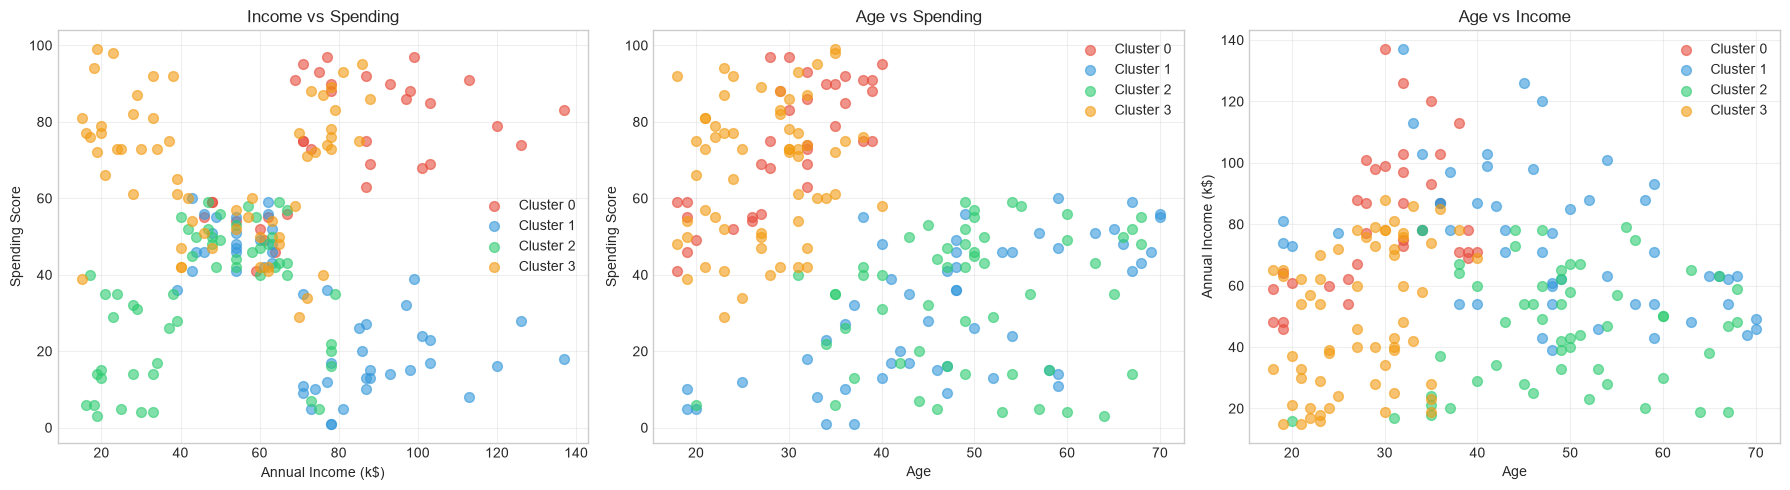

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

if 'Annual Income (k$)' in df.columns and 'Spending Score (1-100)' in df.columns:
    for i in range(best_k):
        cluster_data = df[df['Cluster'] == i]
        axes[0].scatter(cluster_data['Annual Income (k$)'],
                       cluster_data['Spending Score (1-100)'],
                       c=colors[i % len(colors)], label=f'Cluster {i}',
                       alpha=0.6, s=50)
    axes[0].set_xlabel('Annual Income (k$)')
    axes[0].set_ylabel('Spending Score')
    axes[0].set_title('Income vs Spending')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    if 'Age' in df.columns:
        for i in range(best_k):
            cluster_data = df[df['Cluster'] == i]
            axes[1].scatter(cluster_data['Age'],
                           cluster_data['Spending Score (1-100)'],
                           c=colors[i % len(colors)], label=f'Cluster {i}',
                           alpha=0.6, s=50)
        axes[1].set_xlabel('Age')
        axes[1].set_ylabel('Spending Score')
        axes[1].set_title('Age vs Spending')
        axes[1].legend()
        axes[1].grid(alpha=0.3)
        
        for i in range(best_k):
            cluster_data = df[df['Cluster'] == i]
            axes[2].scatter(cluster_data['Age'],
                           cluster_data['Annual Income (k$)'],
                           c=colors[i % len(colors)], label=f'Cluster {i}',
                           alpha=0.6, s=50)
        axes[2].set_xlabel('Age')
        axes[2].set_ylabel('Annual Income (k$)')
        axes[2].set_title('Age vs Income')
        axes[2].legend()
        axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + '/cluster_profiles.png', dpi=300, bbox_inches='tight')
print("✅ Saved: cluster_profiles.png")
plt.show()

In [15]:
print("="*60)
print("✅ PROJECT 3 COMPLETE!")
print("="*60)

print(f"\n🎯 Key Results:")
print(f"   - Optimal clusters: {best_k}")
print(f"   - Silhouette Score: {best_score:.4f}")
print(f"   - PCA components for 95% variance: {n_components_95}")

print(f"\n📁 Files saved to outputs/:")
print("   - pca_variance.png")
print("   - elbow_method.png")
print("   - silhouette_score.png")
print("   - customer_clusters.png")
print("   - cluster_profiles.png")

print("\n🎉 All DecodeLabs projects complete!")

✅ PROJECT 3 COMPLETE!

🎯 Key Results:
   - Optimal clusters: 4
   - Silhouette Score: 0.4164
   - PCA components for 95% variance: 4

📁 Files saved to outputs/:
   - pca_variance.png
   - elbow_method.png
   - silhouette_score.png
   - customer_clusters.png
   - cluster_profiles.png

🎉 All DecodeLabs projects complete!
